In [105]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\AAA.csv")

print(df.shape)
print(df.columns.tolist())

(748, 32)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'ass_5_date', 'ass_5_score', 'clicks_dataplus', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_resource', 'clicks_subpage', 'clicks_url']


In [107]:
selected_cols = [
    'gender', 'region', 'highest_education', 'imd_band', 'age_band',
    'disability', 'num_of_prev_attempts', 'studied_credits',
    'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score',
    'clicks_dataplus', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage',
    'clicks_oucollaborate', 'clicks_oucontent', 'clicks_resource',
    'clicks_subpage', 'clicks_url',
    'final_result'
]

df_sel = df[selected_cols].copy()
print(df_sel.shape)
df_sel.head()

(748, 23)


,gender,region,highest_education,imd_band,age_band,disability,num_of_prev_attempts,studied_credits,ass_1_score,ass_2_score,...,clicks_dataplus,clicks_forumng,clicks_glossary,clicks_homepage,clicks_oucollaborate,clicks_oucontent,clicks_resource,clicks_subpage,clicks_url,final_result
0,M,East Anglian Region,HE Qualification,90-100%,55<=,N,0,240,78.0,85.0,...,0.0,193.0,0.0,138.0,0.0,553.0,13.0,32.0,5.0,Pass
1,F,Scotland,HE Qualification,20-30%,35-55,N,0,60,70.0,68.0,...,10.0,417.0,0.0,324.0,0.0,537.0,12.0,87.0,48.0,Pass
2,F,North Western Region,A Level or Equivalent,30-40%,35-55,Y,0,60,NaN,NaN,...,0.0,126.0,0.0,59.0,0.0,66.0,4.0,22.0,4.0,Withdrawn
3,F,South East Region,A Level or Equivalent,50-60%,35-55,N,0,60,72.0,71.0,...,2.0,634.0,1.0,432.0,0.0,836.0,19.0,144.0,90.0,Pass
4,F,West Midlands Region,Lower Than A Level,50-60%,0-35,N,0,60,69.0,30.0,...,0.0,194.0,4.0,204.0,0.0,494.0,45.0,79.0,14.0,Pass


In [109]:
# imd_band: mode imputation
imd_mode = df_sel['imd_band'].mode()[0]
df_sel['imd_band'] = df_sel['imd_band'].fillna(imd_mode)

# assessment scores: NaN -> -1
ass_cols = ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score']
df_sel[ass_cols] = df_sel[ass_cols].fillna(-1)

# clicks: NaN -> 0
click_cols = [c for c in df_sel.columns if c.startswith('clicks_')]
df_sel[click_cols] = df_sel[click_cols].fillna(0)

print(df_sel.isnull().sum().sum())

0


In [111]:
# ordinal encodings (order matters)
final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
education_map = {
    'No Formal quals': 0, 'Lower Than A Level': 1, 'A Level or Equivalent': 2,
    'HE Qualification': 3, 'Post Graduate Qualification': 4
}
imd_map = {
    '0-10%': 0, '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
age_band_map = {'0-35': 0, '35-55': 1, '55<=': 2}

df_sel['final_result'] = df_sel['final_result'].map(final_result_map)
df_sel['highest_education'] = df_sel['highest_education'].map(education_map)
df_sel['imd_band'] = df_sel['imd_band'].map(imd_map)
df_sel['age_band'] = df_sel['age_band'].map(age_band_map)

# binary encodings
df_sel['gender'] = df_sel['gender'].map({'M': 0, 'F': 1})
df_sel['disability'] = df_sel['disability'].map({'N': 0, 'Y': 1})

# region: label encoding (categorical, no inherent order)
df_sel['region'] = df_sel['region'].astype('category').cat.codes

print(df_sel.isnull().sum().sum())
df_sel.dtypes

46


gender                    int64
region                     int8
highest_education         int64
imd_band                float64
age_band                  int64
disability                int64
num_of_prev_attempts      int64
studied_credits           int64
ass_1_score             float64
ass_2_score             float64
ass_3_score             float64
ass_4_score             float64
ass_5_score             float64
clicks_dataplus         float64
clicks_forumng          float64
clicks_glossary         float64
clicks_homepage         float64
clicks_oucollaborate    float64
clicks_oucontent        float64
clicks_resource         float64
clicks_subpage          float64
clicks_url              float64
final_result              int64
dtype: object

In [113]:
print(df_sel.isnull().sum())

gender                   0
region                   0
highest_education        0
imd_band                46
age_band                 0
disability               0
num_of_prev_attempts     0
studied_credits          0
ass_1_score              0
ass_2_score              0
ass_3_score              0
ass_4_score              0
ass_5_score              0
clicks_dataplus          0
clicks_forumng           0
clicks_glossary          0
clicks_homepage          0
clicks_oucollaborate     0
clicks_oucontent         0
clicks_resource          0
clicks_subpage           0
clicks_url               0
final_result             0
dtype: int64


In [115]:
print(df['imd_band'].unique())

['90-100%' '20-30%' '30-40%' '50-60%' '80-90%' '70-80%' nan '60-70%'
 '40-50%' '10-20' '0-10%']


In [117]:
imd_map = {
    '0-10%': 0, '10-20': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}

df_sel['imd_band'] = df['imd_band'].fillna(df['imd_band'].mode()[0]).map(imd_map)

print(df_sel['imd_band'].isnull().sum())

0


In [119]:
print(df_sel.isnull().sum().sum())
df_sel.dtypes

0


gender                    int64
region                     int8
highest_education         int64
imd_band                  int64
age_band                  int64
disability                int64
num_of_prev_attempts      int64
studied_credits           int64
ass_1_score             float64
ass_2_score             float64
ass_3_score             float64
ass_4_score             float64
ass_5_score             float64
clicks_dataplus         float64
clicks_forumng          float64
clicks_glossary         float64
clicks_homepage         float64
clicks_oucollaborate    float64
clicks_oucontent        float64
clicks_resource         float64
clicks_subpage          float64
clicks_url              float64
final_result              int64
dtype: object

In [121]:
score_cols = ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score']
click_cols = [c for c in df_sel.columns if c.startswith('clicks_')]

for col in score_cols + click_cols:
    df_sel[col] = pd.qcut(df_sel[col], q=4, labels=False, duplicates='drop')

print(df_sel[score_cols + click_cols].nunique())

ass_1_score             4
ass_2_score             4
ass_3_score             4
ass_4_score             4
ass_5_score             4
clicks_dataplus         3
clicks_forumng          4
clicks_glossary         1
clicks_homepage         4
clicks_oucollaborate    2
clicks_oucontent        4
clicks_resource         4
clicks_subpage          4
clicks_url              4
dtype: int64


In [123]:
df_sel = df_sel.drop(columns=['clicks_glossary'])
click_cols = [c for c in click_cols if c != 'clicks_glossary']

print(df_sel.shape)
print(df_sel.columns.tolist())

(748, 22)
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'num_of_prev_attempts', 'studied_credits', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'clicks_dataplus', 'clicks_forumng', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_resource', 'clicks_subpage', 'clicks_url', 'final_result']


In [125]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode

node_names = df_sel.columns.tolist()
data = df_sel.values.astype(float)

nodes = [GraphNode(name) for name in node_names]
node_dict = {name: node for name, node in zip(node_names, nodes)}

print(len(node_names), data.shape)

22 (748, 22)


In [127]:
demographics = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
score_cols = ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score']
click_cols_final = [c for c in click_cols]
course_time_vars = score_cols + click_cols_final + ['final_result']
protected_static = ['studied_credits', 'num_of_prev_attempts']

bk = BackgroundKnowledge()

# Rule 1: course-time variables can't cause demographics
for ct in course_time_vars:
    for d in demographics:
        bk.add_forbidden_by_node(node_dict[ct], node_dict[d])

# Rule 2: nothing can cause gender (gender = root)
for n in node_names:
    if n != 'gender':
        bk.add_forbidden_by_node(node_dict[n], node_dict['gender'])

# Rule 3: assessments must respect sequential order (no backward edges)
for i in range(1, 6):
    for j in range(1, 6):
        if j > i:
            bk.add_forbidden_by_node(node_dict[f'ass_{j}_score'], node_dict[f'ass_{i}_score'])

# Rule 4: course-time variables can't cause studied_credits/num_of_prev_attempts
for ct in course_time_vars:
    for s in protected_static:
        bk.add_forbidden_by_node(node_dict[ct], node_dict[s])

print("Background knowledge rules added.")

Background knowledge rules added.


In [135]:
cg_depth = pc(data, alpha=0.05, indep_test='gsq', background_knowledge=bk, node_names=node_names, depth=3)

print("Number of edges (gsq, depth=3):", cg_depth.G.get_num_edges())

  0%|          | 0/22 [00:00<?, ?it/s]

Number of edges (gsq, depth=3): 23


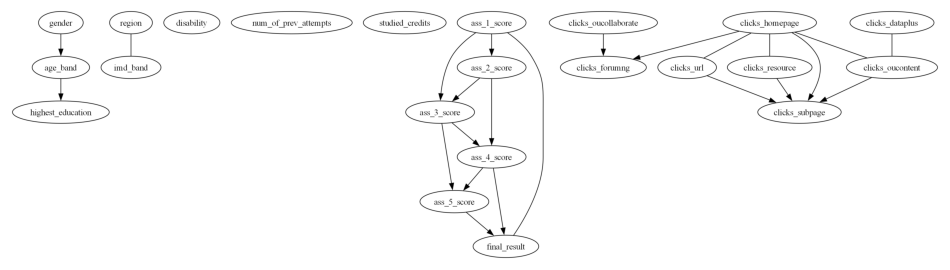

In [139]:
pyd_depth = GraphUtils.to_pydot(cg_depth.G, labels=node_names)
png_bytes_depth = pyd_depth.create_png(prog=dot_path)

img4 = mpimg.imread(io.BytesIO(png_bytes_depth), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img4)
plt.axis('off')
plt.show()

In [133]:
from scipy.stats import chi2_contingency

demographics_vars = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                      'disability', 'num_of_prev_attempts', 'studied_credits']
score_cols = ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score']
click_cols_check = click_cols  # the 8 remaining click columns

def assoc_pvalue(a, b):
    table = pd.crosstab(df_sel[a], df_sel[b])
    chi2, p, dof, exp = chi2_contingency(table)
    return p

print("=== Demographics vs Assessment scores ===")
for d in demographics_vars:
    for s in score_cols:
        p = assoc_pvalue(d, s)
        flag = " <-- significant" if p < 0.05 else ""
        print(f"{d} vs {s}: p={p:.4f}{flag}")

print("\n=== Demographics vs final_result ===")
for d in demographics_vars:
    p = assoc_pvalue(d, 'final_result')
    flag = " <-- significant" if p < 0.05 else ""
    print(f"{d} vs final_result: p={p:.4f}{flag}")

print("\n=== Clicks vs Assessment scores ===")
for c in click_cols_check:
    for s in score_cols:
        p = assoc_pvalue(c, s)
        flag = " <-- significant" if p < 0.05 else ""
        print(f"{c} vs {s}: p={p:.4f}{flag}")

print("\n=== Clicks vs final_result ===")
for c in click_cols_check:
    p = assoc_pvalue(c, 'final_result')
    flag = " <-- significant" if p < 0.05 else ""
    print(f"{c} vs final_result: p={p:.4f}{flag}")

=== Demographics vs Assessment scores ===
gender vs ass_1_score: p=0.0022 <-- significant
gender vs ass_2_score: p=0.0078 <-- significant
gender vs ass_3_score: p=0.0122 <-- significant
gender vs ass_4_score: p=0.0020 <-- significant
gender vs ass_5_score: p=0.0907
region vs ass_1_score: p=0.0140 <-- significant
region vs ass_2_score: p=0.0019 <-- significant
region vs ass_3_score: p=0.0005 <-- significant
region vs ass_4_score: p=0.0003 <-- significant
region vs ass_5_score: p=0.0000 <-- significant
highest_education vs ass_1_score: p=0.0409 <-- significant
highest_education vs ass_2_score: p=0.0278 <-- significant
highest_education vs ass_3_score: p=0.1287
highest_education vs ass_4_score: p=0.2495
highest_education vs ass_5_score: p=0.5438
imd_band vs ass_1_score: p=0.0329 <-- significant
imd_band vs ass_2_score: p=0.1379
imd_band vs ass_3_score: p=0.2103
imd_band vs ass_4_score: p=0.1128
imd_band vs ass_5_score: p=0.3335
age_band vs ass_1_score: p=0.3271
age_band vs ass_2_score: p=

In [141]:
print("=== Click vs Click (pairwise) ===")
for i, c1 in enumerate(click_cols_check):
    for c2 in click_cols_check[i+1:]:
        p = assoc_pvalue(c1, c2)
        flag = " <-- significant" if p < 0.05 else ""
        print(f"{c1} vs {c2}: p={p:.4f}{flag}")

=== Click vs Click (pairwise) ===
clicks_dataplus vs clicks_forumng: p=0.0000 <-- significant
clicks_dataplus vs clicks_homepage: p=0.0000 <-- significant
clicks_dataplus vs clicks_oucollaborate: p=0.0000 <-- significant
clicks_dataplus vs clicks_oucontent: p=0.0000 <-- significant
clicks_dataplus vs clicks_resource: p=0.0000 <-- significant
clicks_dataplus vs clicks_subpage: p=0.0000 <-- significant
clicks_dataplus vs clicks_url: p=0.0000 <-- significant
clicks_forumng vs clicks_homepage: p=0.0000 <-- significant
clicks_forumng vs clicks_oucollaborate: p=0.0000 <-- significant
clicks_forumng vs clicks_oucontent: p=0.0000 <-- significant
clicks_forumng vs clicks_resource: p=0.0000 <-- significant
clicks_forumng vs clicks_subpage: p=0.0000 <-- significant
clicks_forumng vs clicks_url: p=0.0000 <-- significant
clicks_homepage vs clicks_oucollaborate: p=0.0000 <-- significant
clicks_homepage vs clicks_oucontent: p=0.0000 <-- significant
clicks_homepage vs clicks_resource: p=0.0000 <-- sig

In [143]:
raw_click_cols = [c for c in df.columns if c.startswith('clicks_')]

df_sel['total_clicks'] = df[raw_click_cols].fillna(0).sum(axis=1)

# bin the new composite variable
df_sel['total_clicks'] = pd.qcut(df_sel['total_clicks'], q=4, labels=False, duplicates='drop')

# drop the individual click columns
df_sel = df_sel.drop(columns=click_cols)

print(df_sel.shape)
print(df_sel.columns.tolist())
print(df_sel['total_clicks'].nunique())

(748, 15)
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'num_of_prev_attempts', 'studied_credits', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'final_result', 'total_clicks']
4


In [145]:
node_names = df_sel.columns.tolist()
data = df_sel.values.astype(float)

nodes = [GraphNode(name) for name in node_names]
node_dict = {name: node for name, node in zip(node_names, nodes)}

demographics = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
score_cols = ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score']
course_time_vars = score_cols + ['total_clicks', 'final_result']
protected_static = ['studied_credits', 'num_of_prev_attempts']

bk = BackgroundKnowledge()

# Rule 1: course-time variables can't cause demographics
for ct in course_time_vars:
    for d in demographics:
        bk.add_forbidden_by_node(node_dict[ct], node_dict[d])

# Rule 2: nothing can cause gender
for n in node_names:
    if n != 'gender':
        bk.add_forbidden_by_node(node_dict[n], node_dict['gender'])

# Rule 3: assessments must respect sequential order
for i in range(1, 6):
    for j in range(1, 6):
        if j > i:
            bk.add_forbidden_by_node(node_dict[f'ass_{j}_score'], node_dict[f'ass_{i}_score'])

# Rule 4: course-time variables can't cause studied_credits/num_of_prev_attempts
for ct in course_time_vars:
    for s in protected_static:
        bk.add_forbidden_by_node(node_dict[ct], node_dict[s])

print(len(node_names), data.shape)

15 (748, 15)


In [153]:
# Rule 5: final_result cannot cause any assessment score (it's the end-of-course outcome)
for s in score_cols:
    bk.add_forbidden_by_node(node_dict['final_result'], node_dict[s])

cg_final2 = pc(data, alpha=0.05, indep_test='gsq', background_knowledge=bk, node_names=node_names)

print("Number of edges:", cg_final2.G.get_num_edges())

for edge in cg_final2.G.get_graph_edges():
    print(edge.get_node1().get_name(), "->", edge.get_node2().get_name(), "|", edge.get_endpoint1(), edge.get_endpoint2())

  0%|          | 0/15 [00:00<?, ?it/s]

Number of edges: 16
gender -> age_band | TAIL ARROW
region -> imd_band | TAIL TAIL
highest_education -> age_band | TAIL ARROW
studied_credits -> age_band | TAIL ARROW
age_band -> total_clicks | TAIL ARROW
ass_1_score -> ass_2_score | TAIL ARROW
ass_1_score -> ass_3_score | TAIL ARROW
ass_1_score -> final_result | TAIL ARROW
ass_1_score -> total_clicks | TAIL ARROW
ass_2_score -> ass_3_score | TAIL ARROW
ass_2_score -> ass_4_score | TAIL ARROW
ass_3_score -> ass_4_score | TAIL ARROW
ass_3_score -> ass_5_score | TAIL ARROW
ass_4_score -> ass_5_score | TAIL ARROW
ass_4_score -> final_result | TAIL ARROW
ass_5_score -> final_result | TAIL ARROW


In [161]:
# Rule 6: assessment scores cannot cause total_clicks (engagement is the explanatory variable, not the outcome)
for s in score_cols:
    bk.add_forbidden_by_node(node_dict[s], node_dict['total_clicks'])

cg_final3 = pc(data, alpha=0.05, indep_test='gsq', background_knowledge=bk, node_names=node_names)

print("Number of edges:", cg_final3.G.get_num_edges())

for edge in cg_final3.G.get_graph_edges():
    print(edge.get_node1().get_name(), "->", edge.get_node2().get_name(), "|", edge.get_endpoint1(), edge.get_endpoint2())

  0%|          | 0/15 [00:00<?, ?it/s]

Number of edges: 16
gender -> age_band | TAIL ARROW
region -> imd_band | TAIL TAIL
highest_education -> age_band | TAIL ARROW
studied_credits -> age_band | TAIL ARROW
age_band -> total_clicks | TAIL ARROW
ass_1_score -> ass_2_score | TAIL ARROW
ass_1_score -> ass_3_score | TAIL ARROW
ass_1_score -> final_result | TAIL ARROW
total_clicks -> ass_1_score | TAIL ARROW
ass_2_score -> ass_3_score | TAIL ARROW
ass_2_score -> ass_4_score | TAIL ARROW
ass_3_score -> ass_4_score | TAIL ARROW
ass_3_score -> ass_5_score | TAIL ARROW
ass_4_score -> ass_5_score | TAIL ARROW
ass_4_score -> final_result | TAIL ARROW
ass_5_score -> final_result | TAIL ARROW


In [163]:
cg_final = pc(data, alpha=0.05, indep_test='gsq', background_knowledge=bk, node_names=node_names)

print("Number of edges:", cg_final.G.get_num_edges())

  0%|          | 0/15 [00:00<?, ?it/s]

Number of edges: 16


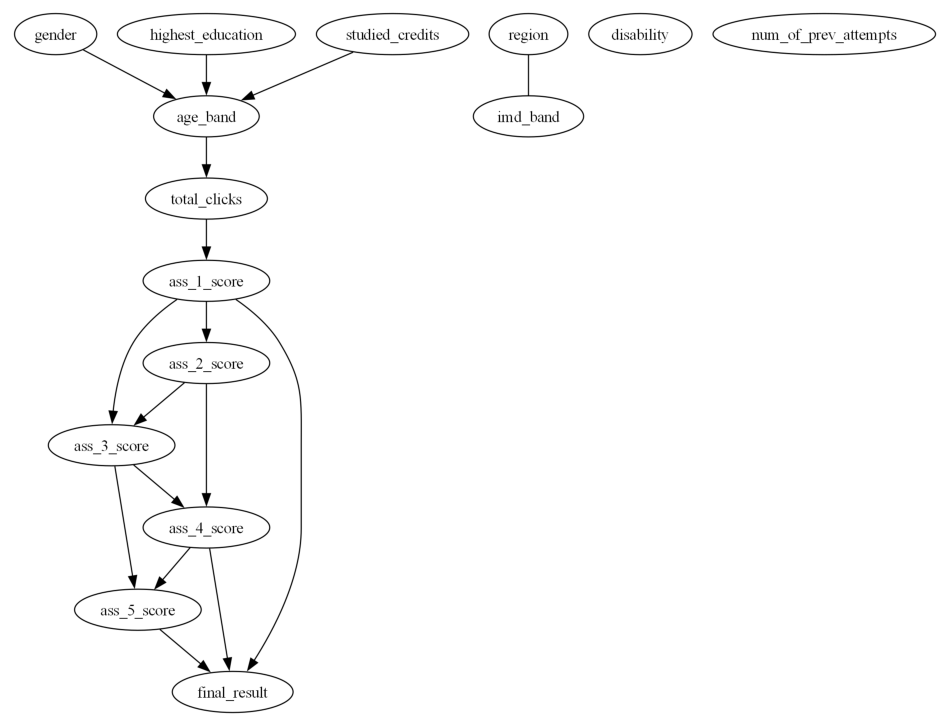

In [165]:
pyd_final = GraphUtils.to_pydot(cg_final.G, labels=node_names)
png_bytes_final = pyd_final.create_png(prog=dot_path)

img5 = mpimg.imread(io.BytesIO(png_bytes_final), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img5)
plt.axis('off')
plt.show()

In [169]:
for edge in cg_final.G.get_graph_edges():
    print(edge.get_node1().get_name(), "->", edge.get_node2().get_name(), "|", edge.get_endpoint1(), edge.get_endpoint2())

gender -> age_band | TAIL ARROW
region -> imd_band | TAIL TAIL
highest_education -> age_band | TAIL ARROW
studied_credits -> age_band | TAIL ARROW
age_band -> total_clicks | TAIL ARROW
ass_1_score -> ass_2_score | TAIL ARROW
ass_1_score -> ass_3_score | TAIL ARROW
ass_1_score -> final_result | TAIL ARROW
total_clicks -> ass_1_score | TAIL ARROW
ass_2_score -> ass_3_score | TAIL ARROW
ass_2_score -> ass_4_score | TAIL ARROW
ass_3_score -> ass_4_score | TAIL ARROW
ass_3_score -> ass_5_score | TAIL ARROW
ass_4_score -> ass_5_score | TAIL ARROW
ass_4_score -> final_result | TAIL ARROW
ass_5_score -> final_result | TAIL ARROW
